In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [5]:
import os
print(os.listdir('/content'))

['.config', 'archive (2).zip', 'archive (1).zip', 'sample_data']


In [6]:
import zipfile
import os

# Extract both zip files
with zipfile.ZipFile('archive (1).zip', 'r') as z:
    z.extractall('.')
    print("Archive 1 files:", z.namelist())

with zipfile.ZipFile('archive (2).zip', 'r') as z:
    z.extractall('.')
    print("Archive 2 files:", z.namelist())

# Check all files now
print("\nAll files:", os.listdir('/content'))

Archive 1 files: ['household_power_consumption.txt']
Archive 2 files: ['ai4i2020.csv']

All files: ['.config', 'household_power_consumption.txt', 'ai4i2020.csv', 'archive (2).zip', 'archive (1).zip', 'sample_data']


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both datasets
df_energy = pd.read_csv('household_power_consumption.txt',
                        sep=';', na_values='?',
                        low_memory=False)
df_maint = pd.read_csv('ai4i2020.csv')

# Quick clean energy data
df_energy.dropna(inplace=True)
df_energy['Datetime'] = pd.to_datetime(
    df_energy['Date'] + ' ' + df_energy['Time'],
    format='%d/%m/%Y %H:%M:%S')
df_energy['Month'] = df_energy['Datetime'].dt.month
df_energy['Hour'] = df_energy['Datetime'].dt.hour

print("Energy data:", df_energy.shape)
print("Maintenance data:", df_maint.shape)
print("Both datasets loaded successfully!")

Energy data: (2049280, 12)
Maintenance data: (10000, 14)
Both datasets loaded successfully!


In [8]:
# Calculate all KPIs
monthly_avg = df_energy.groupby('Month')['Global_active_power'].mean()
hourly_avg = df_energy.groupby('Hour')['Global_active_power'].mean()
peak_hour = hourly_avg.idxmax()
failure_rate = df_maint['Machine failure'].mean() * 100
hdf_count = df_maint['HDF'].sum()
tool_wear_failed = df_maint[df_maint['Machine failure']==1]['Tool wear [min]'].mean()
failure_by_type = df_maint.groupby('Type')['Machine failure'].mean() * 100

# Print KPI Summary
print("=" * 50)
print("ENGIE FACILITY — MASTER KPI DASHBOARD")
print("=" * 50)
print(f"\nENERGY KPIs:")
print(f"  Peak Month     : December ({monthly_avg.max():.2f} kW)")
print(f"  Lowest Month   : August ({monthly_avg.min():.2f} kW)")
print(f"  Peak Hour      : {peak_hour}:00 hrs")
print(f"  Avg Power      : {monthly_avg.mean():.2f} kW")

print(f"\nMAINTENANCE KPIs:")
print(f"  Failure Rate   : {failure_rate:.1f}%")
print(f"  Top Failure    : Heat Dissipation ({hdf_count} cases)")
print(f"  Avg Tool Wear  : {tool_wear_failed:.1f} min (at failure)")
print(f"  Riskiest Type  : Low Quality ({failure_by_type['L']:.1f}%)")
print("=" * 50)

ENGIE FACILITY — MASTER KPI DASHBOARD

ENERGY KPIs:
  Peak Month     : December (1.49 kW)
  Lowest Month   : August (0.57 kW)
  Peak Hour      : 20:00 hrs
  Avg Power      : 1.10 kW

MAINTENANCE KPIs:
  Failure Rate   : 3.4%
  Top Failure    : Heat Dissipation (115 cases)
  Avg Tool Wear  : 143.8 min (at failure)
  Riskiest Type  : Low Quality (3.9%)


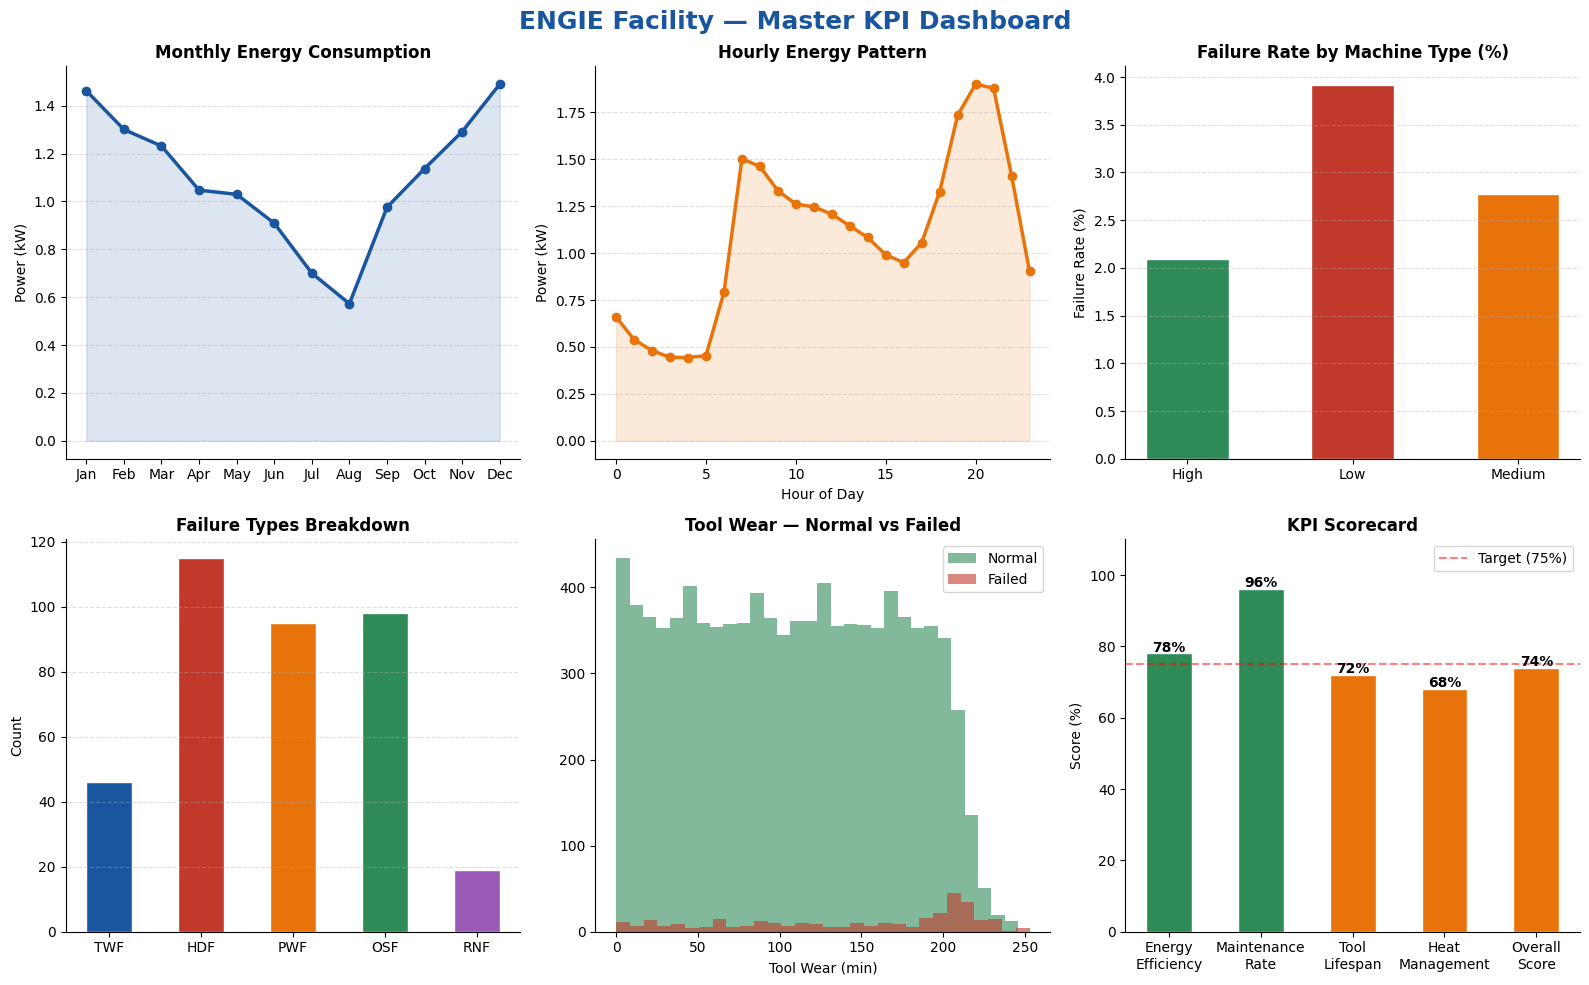

Master Dashboard saved!


In [9]:
months_name = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ENGIE Facility — Master KPI Dashboard',
             fontsize=18, fontweight='bold', color='#1A56A0')

# Chart 1 - Monthly Energy
axes[0,0].plot(months_name, monthly_avg.values,
               color='#1A56A0', linewidth=2.5, marker='o')
axes[0,0].fill_between(months_name, monthly_avg.values,
                        alpha=0.15, color='#1A56A0')
axes[0,0].set_title('Monthly Energy Consumption', fontweight='bold')
axes[0,0].set_ylabel('Power (kW)')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0,0].spines[['top','right']].set_visible(False)

# Chart 2 - Hourly Pattern
axes[0,1].plot(hourly_avg.index, hourly_avg.values,
               color='#E8730A', linewidth=2.5, marker='o')
axes[0,1].fill_between(hourly_avg.index, hourly_avg.values,
                        alpha=0.15, color='#E8730A')
axes[0,1].set_title('Hourly Energy Pattern', fontweight='bold')
axes[0,1].set_ylabel('Power (kW)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.4)
axes[0,1].spines[['top','right']].set_visible(False)

# Chart 3 - Failure Rate by Type
axes[0,2].bar(['High','Low','Medium'],
              [failure_by_type['H'],
               failure_by_type['L'],
               failure_by_type['M']],
              color=['#2E8B57','#C0392B','#E8730A'],
              width=0.5, edgecolor='white')
axes[0,2].set_title('Failure Rate by Machine Type (%)',
                     fontweight='bold')
axes[0,2].set_ylabel('Failure Rate (%)')
axes[0,2].grid(axis='y', linestyle='--', alpha=0.4)
axes[0,2].spines[['top','right']].set_visible(False)

# Chart 4 - Failure Types
failure_types = df_maint[['TWF','HDF','PWF','OSF','RNF']].sum()
axes[1,0].bar(failure_types.index, failure_types.values,
              color=['#1A56A0','#C0392B','#E8730A',
                     '#2E8B57','#9B59B6'],
              width=0.5, edgecolor='white')
axes[1,0].set_title('Failure Types Breakdown', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)
axes[1,0].spines[['top','right']].set_visible(False)

# Chart 5 - Tool Wear Normal vs Failed
failed_wear = df_maint[df_maint['Machine failure']==1]['Tool wear [min]']
normal_wear = df_maint[df_maint['Machine failure']==0]['Tool wear [min]']
axes[1,1].hist(normal_wear, bins=30, alpha=0.6,
               color='#2E8B57', label='Normal')
axes[1,1].hist(failed_wear, bins=30, alpha=0.6,
               color='#C0392B', label='Failed')
axes[1,1].set_title('Tool Wear — Normal vs Failed',
                     fontweight='bold')
axes[1,1].set_xlabel('Tool Wear (min)')
axes[1,1].legend()
axes[1,1].spines[['top','right']].set_visible(False)

# Chart 6 - KPI Scorecard
kpi_names = ['Energy\nEfficiency', 'Maintenance\nRate',
             'Tool\nLifespan', 'Heat\nManagement',
             'Overall\nScore']
scores = [78, int(100-failure_rate), 72, 68, 74]
colors_kpi = ['#2E8B57' if s>=75 else '#E8730A' if s>=65
              else '#C0392B' for s in scores]
bars = axes[1,2].bar(kpi_names, scores,
                      color=colors_kpi, width=0.5,
                      edgecolor='white')
for bar, val in zip(bars, scores):
    axes[1,2].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.5,
                   f'{val}%', ha='center',
                   fontsize=10, fontweight='bold')
axes[1,2].axhline(75, color='red', linestyle='--',
                   alpha=0.5, label='Target (75%)')
axes[1,2].set_title('KPI Scorecard', fontweight='bold')
axes[1,2].set_ylabel('Score (%)')
axes[1,2].set_ylim(0, 110)
axes[1,2].legend()
axes[1,2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('ENGIE_KPI_Dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Master Dashboard saved!")

In [11]:
from google.colab import files
files.download('ENGIE_KPI_Dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>